In [29]:
import os
import sys
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
from glob import glob
from sklearn.utils import resample

import pymbar
from pymbar.mbar_pmf2 import mbar_pmf

os.makedirs('img', exist_ok=True)
os.makedirs('freefile', exist_ok=True)
os.makedirs('reweighting_entropy', exist_ok=True)

In [44]:
pwd

'/archive/projects/ippoi/qmmm/old/wildtype/mbar'

In [30]:
n_windows = 42
val_min = -1.90 # value of r2 and r3 in cv.rst of first window (00)
val_max = 2.20 # value of r2 and r3 in cv.rst of last window (41)
force_constant = 150.0 * 2 # value of rk2 and rk3 in cv.rst (should be the same in all cv.rst files)

val0_k = np.linspace(val_min, val_max, n_windows) # creates range of value includeing -1.90 to 2.20 iterate by 0.10 implied by number of iwndows
K_k = np.ones(n_windows) * 300.0 # array of force constant
nbins = n_windows - 1 # nbins = number of windows minus 1

startstep = 3000 # used as the iterate "all_step6.cv", i.e. only take data from step3000 to end 
fname = f"iter{startstep}"

In [31]:
# from glob import glob
val_kn = []
for i in range(n_windows):
    fnames = sorted(glob('../%02d/all_step6.cv' % i))
    arrays = [np.loadtxt(f, usecols=1)[startstep::] for f in fnames[:]]
    val_kn.append(np.concatenate(arrays))


In [32]:
for i in range(n_windows):
    print("Window %02d:" % i, pymbar.timeseries.subsampleCorrelatedData(val_kn[i], conservative=True))

Window 00: range(0, 1320, 2)
Window 01: range(0, 1320, 2)
Window 02: range(0, 1320, 2)
Window 03: range(0, 1320, 2)
Window 04: range(0, 1320, 2)
Window 05: range(0, 1320, 2)
Window 06: range(0, 1320, 2)
Window 07: range(0, 1320, 2)
Window 08: range(0, 1320, 2)
Window 09: range(0, 1320, 2)
Window 10: range(0, 1320, 2)
Window 11: range(0, 1320)
Window 12: range(0, 1320, 2)
Window 13: range(0, 1320, 2)
Window 14: range(0, 1320, 2)
Window 15: range(0, 1320, 2)
Window 16: range(0, 1320, 2)
Window 17: range(0, 1320, 2)
Window 18: range(0, 1320, 2)
Window 19: range(0, 1320, 3)
Window 20: range(0, 1320, 4)
Window 21: range(0, 1320, 2)
Window 22: range(0, 1320, 3)
Window 23: range(0, 1320, 3)
Window 24: range(0, 1320, 3)
Window 25: range(0, 1320, 3)
Window 26: range(0, 1320, 2)
Window 27: range(0, 1320, 2)
Window 28: range(0, 1320, 2)
Window 29: range(0, 1320, 2)
Window 30: range(0, 1320, 2)
Window 31: range(0, 1320, 2)
Window 32: range(0, 1320, 2)
Window 33: range(0, 1320, 2)
Window 34: range(

In [33]:
mbar = mbar_pmf(val_kn, val0_k, K_k, force_constant)

K (total states) = 42, total samples = 55440
N_k = 
[1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320
 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320
 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320 1320]
There are 42 states with samples.
Initial dimensionless free energies with method BAR
f_k = 
[ 0.          0.21744422  0.58896313  1.17588913  2.42440466  3.69482057
  4.66449744  5.75055257  7.39610581  9.5693967  11.4975111  13.63616957
 16.06866064 18.54384482 21.07709796 23.77916067 26.49764808 28.69137393
 30.6075898  32.79674184 35.06656647 35.83934525 35.63346701 35.36282937
 34.51204762 33.33978245 32.33587746 30.21153574 28.02511629 26.10896714
 24.30447949 23.53548414 22.77184674 21.60898093 20.53226757 19.13091751
 18.21621119 18.33011307 18.63800647 19.3893782  20.05444497 20.16204553]
Determining dimensionless free energies by Newton-Raphson / self-consistent iteration.
self consistent iteration gradient norm is

In [34]:
bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins)
bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins, uncertainties='from-specified', pmf_reference=f_i[:20].argmin())

np.savetxt(f"freefile/mbar_{fname}", np.column_stack((bin_centers, f_i, df_i))) # save pmf data
np.savetxt(f"reweighting_entropy/mbar_{fname}", np.column_stack((bin_centers, f_i, df_i))) # save reweighting entropy

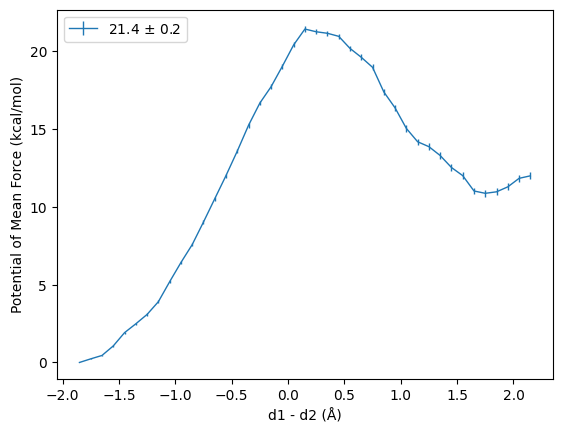

In [41]:
pmf = f"freefile/mbar_{fname}"
initial0 = np.loadtxt(pmf)

dgd, edgd = np.round(initial0[:,1].max() - initial0[:10,1].min(),1), np.round(initial0[initial0[:,1].argmax()][2],1)

plt.errorbar(initial0[:,0], initial0[:,1] - initial0[:10,1].min(), yerr=initial0[:,2], linewidth=1, label=f"{dgd} $\pm$ {edgd}")
plt.xlabel("d1 - d2 (Å)")
plt.ylabel("Potential of Mean Force (kcal/mol)")
plt.legend(loc=2)
plt.savefig(f"img/pmf-{fname}.png", dpi=300)
plt.show()
# plt.errorbar(bin_centers, df_i, linewidth=1)